# Dataset Utilities in Scikit-Learn

# Core Functions in Scikit-Learn

- **transform()**  
  Transform the dataset.

- **fit()**  
  Learn the parameters from the dataset.

- **fit_transform()**  
  Fit the parameters and then transform the dataset.

- **predict()**  
  Take dataset as input and return predictions.

- **score()**  
  Measure the quality of predictions.


# Modules and Their Functionalities

- **sklearn.datasets**  
  Loading datasets.

- **sklearn.preprocessing**  
  Scaling, centering, normalization, and binarization methods.

- **sklearn.impute**  
  Filling missing values.

- **sklearn.feature_selection**  
  Implement feature selection algorithms.

- **sklearn.feature_extraction**  
  Implement feature extraction from raw data.

In [1]:
from sklearn.linear_model import LinearRegression

# Sample data
X = [[1], [2], [3], [4]]
y = [2, 4, 6, 8]

model = LinearRegression()

model.fit(X, y)   # Learning happens here

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [2]:
model.predict([[5]])

array([10.])

In [ ]:
model.score(X,y)

#if 1.0 perfect prediction

1.0

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X) #learn mean $ std
X_scaled = scaler.transform(X)
X_scaled

array([[-1.34164079],
       [-0.4472136 ],
       [ 0.4472136 ],
       [ 1.34164079]])

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = [[1], [2], [3], [4]]
y = [2, 4, 6, 8]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model
model = LinearRegression()
model.fit(X_scaled, y)

# Prediction
pred = model.predict(scaler.transform([[5]]))

# Score
accuracy = model.score(X_scaled, y)

print("Prediction:", pred)
print("Score:", accuracy)


Prediction: [10.]
Score: 1.0


# Implements Supervised and Unsupervised Models

## Regression
- `sklearn.linear_model`  
  - Linear  
  - Ridge  
  - Lasso  
  - Model  
- `sklearn.tree`

## Classification
- `sklearn.linear_model`
- `sklearn.svm`
- `sklearn.tree`
- `sklearn.neighbors`
- `sklearn.naive_bayes`
- `sklearn.multiclass`

In [7]:
# Ridge Regression (L2 Regularization)

from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)
model.fit(X,y)
print (model.predict([[5]]))

[9.16666667]


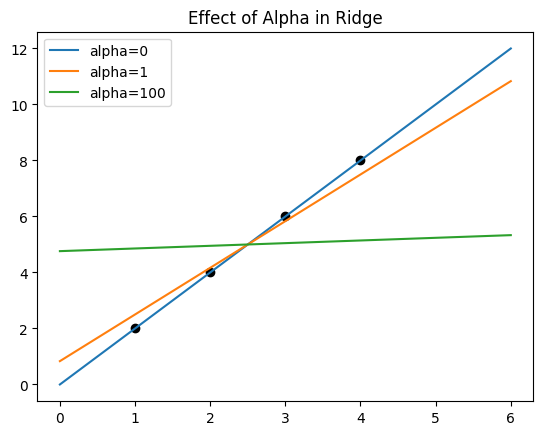

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# Data
X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])

# Models with different alpha
alphas = [0, 1, 100]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X, y)
    
    X_test = np.linspace(0, 6, 100).reshape(-1,1)
    y_pred = model.predict(X_test)
    
    plt.plot(X_test, y_pred, label=f'alpha={a}')

plt.scatter(X, y, color='black')
plt.legend()
plt.title("Effect of Alpha in Ridge")
plt.show()

In [ ]:
#Lasso Regression (L1 Regularization) = Can remove unnecessary features (feature selection)
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X, y)

print(model.predict([[5]]))

[9.8]


# CLASSIFICATION MODELS

In [11]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

X = [[1], [2], [3], [4]]
y = [0, 0, 1, 1]

model = LogisticRegression()
model.fit(X, y)

print(model.predict([[2.5]]))   # 0 or 1

[1]


In [12]:
# SVM (Support Vector Machine)

from sklearn.svm import SVC

model = SVC()
model.fit(X, y)

print(model.predict([[2.5]]))

[1]


In [13]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X, y)

print(model.predict([[2.5]]))

[0]


In [14]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

print(model.predict([[2.5]]))

[0]


#Naive Bayes
$$
P(A|B) = \frac{P(B|A)\, P(A)}{P(B)}
$$

✔ Fast
✔ Works well for text (spam, sentiment)
✔ Needs less data

In [ ]:
#Naive Bayes
#Naive Bayes predicts class based on probability and assumes all features are independent.
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X, y)

print(model.predict([[2.5]]))

[0]


Class A, Class B, Class C
A vs (B + C)
B vs (A + C)
C vs (A + B)
Each model gives a score/probability
Choose highest score

In [ ]:
#Multiclass (OneVsRest)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

X = [[1], [2], [3], [4]]
y = [0, 1, 2, 2]

model = OneVsRestClassifier(LogisticRegression())
model.fit(X, y)

print(model.predict([[2.5]]))

| Type           | Model       | Idea              |
| -------------- | ----------- | ----------------- |
| Regression     | Linear      | Straight line     |
| Regression     | Ridge       | Avoid overfit     |
| Regression     | Lasso       | Feature selection |
| Regression     | Tree        | Rule-based        |
| Classification | Logistic    | Probability       |
| Classification | SVM         | Best boundary     |
| Classification | KNN         | Nearest points    |
| Classification | Naive Bayes | Probability       |
| Classification | Tree        | Rules             |
| Classification | Multiclass  | Multiple labels   |


# Additional Modules and Their Functionalities

- **sklearn.multioutput**  
  Implements multi-output classification and regression.

- **sklearn.cluster**  
  Implements many popular clustering algorithms.

In [16]:
#Used when one input → multiple outputs
# Ex: Predict 2 outputs (like math & science marks)

from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

# Input (study hours)
X = np.array([[1], [2], [3], [4]])

# Output (Math marks, Science marks)
y = np.array([
    [50, 60],
    [60, 65],
    [70, 75],
    [80, 85]
])

# Model
model = MultiOutputRegressor(LinearRegression())
model.fit(X, y)

# Predict for 5 hours study
prediction = model.predict([[5]])

print(prediction)

[[90.  92.5]]


In [ ]:
# Used when no labels (unsupervised learning) - group similar data
from sklearn.cluster import KMeans
import numpy as np

# Data (height, weight)
X = np.array([
    [150, 50],
    [160, 60],
    [170, 70],
    [180, 80]
])

# Model (2 clusters)
model = KMeans(n_clusters=2)

model.fit(X)

# Cluster labels
print(model.labels_)

# Predict cluster for new data
print(model.predict([[155, 55]]))

[1 1 0 0]
[1]


# Model Selection API

- **sklearn.model_selection**  
  Implements various model selection strategies such as:
  - Cross-validation  
  - Hyperparameter tuning  
  - Plotting learning curves

#K-Fold Cross Validation
#Instead of training once, we split data multiple times and test.
#A fold = one split (one part) of your dataset
[1, 2, 3, 4, 5]
Fold 1 → [1]
Fold 2 → [2]
Fold 3 → [3]
Fold 4 → [4]
Fold 5 → [5]

Iterations:

1️⃣ Test: [1] → Train: [2,3,4,5]
2️⃣ Test: [2] → Train: [1,3,4,5]
3️⃣ Test: [3] → Train: [1,2,4,5]
4️⃣ Test: [4] → Train: [1,2,3,5]
5️⃣ Test: [5] → Train: [1,2,3,4]

You get 5 scores → take average

In [ ]:
#K-Fold Cross Validation

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=2)

print(scores)
print("Average score:", scores.mean())

[1. 1.]
Average score: 1.0


In [22]:
#Hyperparameter Tuning (Find best model settings)
#We try different values and pick the best one
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

X = [[1], [2], [3], [4]]
y = [0, 0, 1, 1]

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [1, 2]
}

grid = GridSearchCV(model, param_grid, cv=2)
grid.fit(X, y)

print("Best parameter:", grid.best_params_)

Best parameter: {'n_neighbors': 1}


# Model Inspection API

- **sklearn.inspection**  
  Includes tools for model inspection, such as:
  - Visualizing model behavior  
  - Understanding feature importance  
  - Partial dependence plots  
  - Permutation importance


## load_*
- Used to **load small toy datasets** that are bundled with scikit-learn.
- Examples:
  - `load_iris()` → Iris flower dataset
  - `load_digits()` → Handwritten digits dataset
  - `load_wine()` → Wine classification dataset
- Typically return a `Bunch` object (dictionary-like) with `.data` and `.target`.



In [ ]:
#No internet needed
#Comes with sklearn
from sklearn.datasets import load_iris

data = load_iris()

# Features (input)
X = data.data

# Target (output)
y = data.target

print("Features:\n", X[:5])
print("Target:\n", y[:5])

Features:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Target:
 [0 0 0 0 0]


## fetch_*
- Used to **download larger real-world datasets** from the internet.
- Examples:
  - `fetch_20newsgroups()` → Text dataset of newsgroup posts
  - `fetch_california_housing()` → Housing dataset
  - `fetch_openml()` → Access datasets hosted on OpenML
- Often return data in a more complex structure, sometimes requiring preprocessing.



In [ ]:
#Requires internet
#Downloads real-world data
#“load_* is used for small built-in datasets, while fetch_* downloads larger real-world datasets from the internet
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [25]:
type(data)

sklearn.utils._bunch.Bunch

In [ ]:
data.data #Input values (X)
data.target # Output labels (y)
data.feature_names #names of input columns (features)
data.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [ ]:
#data.DESCR is a documentation of the dataset.
from sklearn.datasets import load_iris

data = load_iris()

print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## make_*
- Used to **generate synthetic datasets** for testing and experimentation.
- Examples:
  - `make_classification()` → Create a random classification dataset
  - `make_regression()` → Create a random regression dataset
  - `make_blobs()` → Generate clusters for clustering tasks
- Useful for benchmarking algorithms or demonstrations.

| Parameter     | Meaning                    |
| ------------- | -------------------------- |
| n_features    | Total columns              |
| n_informative | Useful features            |
| n_redundant   | Duplicate/useless features |


In [ ]:
#n_informative = 2
#n_redundant = 2

#n_informative + n_redundant = 4


from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=10,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

print("X:\n", X)
print("y:\n", y)

X:
 [[ 1.06833894 -0.97007347]
 [-1.14021544 -0.83879234]
 [-2.8953973   1.97686236]
 [-0.72063436 -0.96059253]
 [-1.96287438 -0.99225135]
 [-0.9382051  -0.54304815]
 [ 1.72725924 -1.18582677]
 [ 1.77736657  1.51157598]
 [ 1.89969252  0.83444483]
 [-0.58723065 -1.97171753]]
y:
 [1 0 0 0 0 1 1 1 1 0]


In [31]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=10,
    n_features=1,
    noise=5,
    random_state=42
)

print(X)
print(y)

[[-0.1382643 ]
 [-0.46947439]
 [ 0.76743473]
 [-0.23413696]
 [-0.23415337]
 [ 0.54256004]
 [ 0.49671415]
 [ 1.52302986]
 [ 1.57921282]
 [ 0.64768854]]
[ -7.13440439 -12.05293549  10.24184526 -11.87657444  -0.17526756
  -0.83300707   6.17460263  32.44433378  26.57380152  -1.28615034]


hello